## Importing:

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Configuration:

In [29]:
CONFIG = {

    "input_dim": 784,
    "hidden_dim": 400,
    "latent_dim": 64,

    "num_embeddings": 128,
    "beta": 0.25,

    "batch_size": 128,
    "epochs": 20,
    "learning_rate": 1e-3
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Loading MNIST:

In [30]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"]
)


## Encoder, Codebook and Decoder:

In [31]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(CONFIG["input_dim"], CONFIG["hidden_dim"])
        self.fc2 = nn.Linear(CONFIG["hidden_dim"], CONFIG["latent_dim"])

    def forward(self, x):

        x = x.view(-1, CONFIG["input_dim"])

        h = F.relu(self.fc1(x))

        z = self.fc2(h)

        return z

class VectorQuantizer(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(
            CONFIG["num_embeddings"],
            CONFIG["latent_dim"]
        )

        self.embedding.weight.data.uniform_(
            -1 / CONFIG["num_embeddings"],
            1 / CONFIG["num_embeddings"]
        )

    def forward(self, z):

        distances = (
            torch.sum(z ** 2, dim=1, keepdim=True)
            + torch.sum(self.embedding.weight ** 2, dim=1)
            - 2 * torch.matmul(z, self.embedding.weight.t())
        )

        encoding_indices = torch.argmin(distances, dim=1)

        z_q = self.embedding(encoding_indices)

        # Straight-through estimator
        z_q_st = z + (z_q - z).detach()

        return z_q_st, z_q, encoding_indices

class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(CONFIG["latent_dim"], CONFIG["hidden_dim"])
        self.fc2 = nn.Linear(CONFIG["hidden_dim"], CONFIG["input_dim"])

    def forward(self, z):

        h = F.relu(self.fc1(z))

        x = torch.sigmoid(self.fc2(h))

        return x

## Model Definition:

In [32]:
class VQVAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.vq = VectorQuantizer()
        self.decoder = Decoder()

    def forward(self, x):

        z = self.encoder(x)

        z_q_st, z_q, indices = self.vq(z)

        recon = self.decoder(z_q_st)

        return recon, z, z_q, indices

## Loss function:

In [33]:

def vqvae_loss(x, recon, z, z_q):

    x = x.view(-1, CONFIG["input_dim"])

    recon_loss = F.mse_loss(recon, x)

    codebook_loss = F.mse_loss(z_q, z.detach())

    commitment_loss = F.mse_loss(z, z_q.detach())

    loss = recon_loss + codebook_loss + CONFIG["beta"] * commitment_loss

    return loss

## Training loop:


In [25]:
model = VQVAE().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

train_losses = []

for epoch in range(CONFIG["epochs"]):

    total_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        optimizer.zero_grad()

        recon, z, z_q, _ = model(x)

        loss = vqvae_loss(x, recon, z, z_q)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print("Epoch:", epoch + 1, "Loss:", epoch_loss)

Epoch: 1 Loss: 0.21497063770858463
Epoch: 2 Loss: 0.0718090020771474
Epoch: 2 Loss: 0.0718090020771474
Epoch: 3 Loss: 0.07631524969964648
Epoch: 3 Loss: 0.07631524969964648
Epoch: 4 Loss: 0.07840289768061913
Epoch: 4 Loss: 0.07840289768061913
Epoch: 5 Loss: 0.08076354354492891
Epoch: 5 Loss: 0.08076354354492891
Epoch: 6 Loss: 0.08230412872170588
Epoch: 6 Loss: 0.08230412872170588
Epoch: 7 Loss: 0.08274343975190161
Epoch: 7 Loss: 0.08274343975190161
Epoch: 8 Loss: 0.08294141008210842
Epoch: 8 Loss: 0.08294141008210842
Epoch: 9 Loss: 0.08338632053340167
Epoch: 9 Loss: 0.08338632053340167
Epoch: 10 Loss: 0.08387464696346823
Epoch: 10 Loss: 0.08387464696346823
Epoch: 11 Loss: 0.0845747353997566
Epoch: 11 Loss: 0.0845747353997566
Epoch: 12 Loss: 0.08475156293621958
Epoch: 12 Loss: 0.08475156293621958
Epoch: 13 Loss: 0.08475790299904118
Epoch: 13 Loss: 0.08475790299904118
Epoch: 14 Loss: 0.08498788221494984
Epoch: 14 Loss: 0.08498788221494984
Epoch: 15 Loss: 0.08534291780579573
Epoch: 15 Los

## Testing:

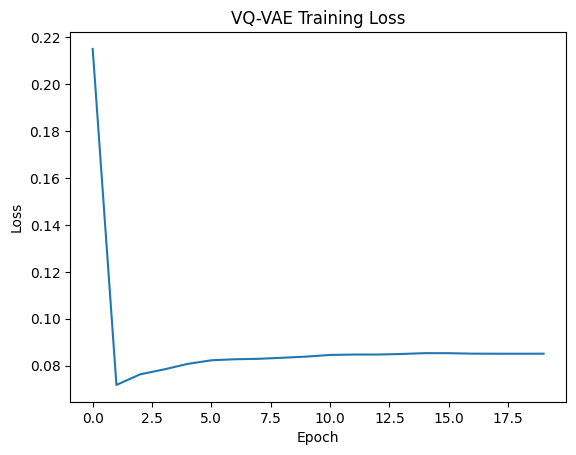

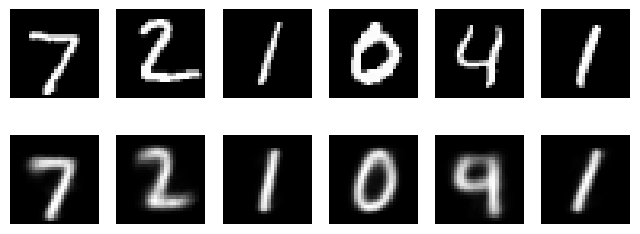

In [34]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VQ-VAE Training Loss")
plt.show()
model.eval()
x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():

    recon, _, _, _ = model(x)
x = x.cpu()
recon = recon.view(-1, 1, 28, 28).cpu()
plt.figure(figsize=(8,3))
for i in range(6):
    plt.subplot(2,6,i+1)
    plt.imshow(x[i][0], cmap="gray")
    plt.axis("off")
    plt.subplot(2,6,i+7)
    plt.imshow(recon[i][0], cmap="gray")
    plt.axis("off")

In [27]:
## Comprehensive Testing and Evaluation

print("=" * 80)
print("VQ-VAE MODEL TESTING AND EVALUATION")
print("=" * 80)

try:
    # Test 1: Model Forward Pass
    print("\n[TEST 1] Model Forward Pass")
    print("-" * 80)
    model.eval()
    
    test_batch, _ = next(iter(test_loader))
    test_batch = test_batch.to(device)
    print(f"✓ Input batch shape: {test_batch.shape}")
    
    with torch.no_grad():
        recon, z, z_q, indices = model(test_batch)
    
    print(f"✓ Reconstruction shape: {recon.shape}")
    print(f"✓ Encoded latent shape: {z.shape}")
    print(f"✓ Quantized latent shape: {z_q.shape}")
    print(f"✓ Encoding indices shape: {indices.shape}")
    print(f"✓ Forward pass successful!")
    
except Exception as e:
    print(f"✗ ERROR in forward pass: {e}")
    import traceback
    traceback.print_exc()

# Test 2: Loss Computation
print("\n[TEST 2] Loss Computation on Test Batch")
print("-" * 80)

try:
    with torch.no_grad():
        recon, z, z_q, indices = model(test_batch)
        loss = vqvae_loss(test_batch, recon, z, z_q)
    
    print(f"✓ Total VQ-VAE Loss: {loss.item():.6f}")
    
    # Break down loss components
    test_batch_flat = test_batch.view(-1, CONFIG["input_dim"])
    recon_loss = F.mse_loss(recon, test_batch_flat)
    codebook_loss = F.mse_loss(z_q, z.detach())
    commitment_loss = F.mse_loss(z, z_q.detach())
    
    print(f"  ├─ Reconstruction Loss: {recon_loss.item():.6f}")
    print(f"  ├─ Codebook Loss: {codebook_loss.item():.6f}")
    print(f"  └─ Commitment Loss (β={CONFIG['beta']}): {commitment_loss.item():.6f}")
    
except Exception as e:
    print(f"✗ ERROR in loss computation: {e}")
    import traceback
    traceback.print_exc()

# Test 3: Codebook Usage
print("\n[TEST 3] Codebook Statistics")
print("-" * 80)

try:
    with torch.no_grad():
        # Get all encodings from test set
        all_indices = []
        for x, _ in test_loader:
            x = x.to(device)
            z = model.encoder(x)
            _, _, indices = model.vq(z)
            all_indices.append(indices.cpu())
        
        all_indices = torch.cat(all_indices)
        unique_indices = torch.unique(all_indices)
        
    codebook_usage = len(unique_indices)
    codebook_utilization = (codebook_usage / CONFIG["num_embeddings"]) * 100
    
    print(f"✓ Total codebook embeddings: {CONFIG['num_embeddings']}")
    print(f"✓ Used embeddings: {codebook_usage}")
    print(f"✓ Codebook utilization: {codebook_utilization:.2f}%")
    print(f"✓ Unused embeddings: {CONFIG['num_embeddings'] - codebook_usage}")
    
except Exception as e:
    print(f"✗ ERROR in codebook analysis: {e}")
    import traceback
    traceback.print_exc()

# Test 4: Reconstruction Quality
print("\n[TEST 4] Reconstruction Quality Metrics")
print("-" * 80)

try:
    with torch.no_grad():
        test_batch, _ = next(iter(test_loader))
        test_batch = test_batch.to(device)
        recon, _, _, _ = model(test_batch)
    
    test_batch_flat = test_batch.view(-1, CONFIG["input_dim"])
    
    # MSE
    mse = F.mse_loss(recon, test_batch_flat)
    
    # RMSE
    rmse = torch.sqrt(mse)
    
    # MAE
    mae = F.l1_loss(recon, test_batch_flat)
    
    print(f"✓ Mean Squared Error (MSE): {mse.item():.6f}")
    print(f"✓ Root Mean Squared Error (RMSE): {rmse.item():.6f}")
    print(f"✓ Mean Absolute Error (MAE): {mae.item():.6f}")
    
except Exception as e:
    print(f"✗ ERROR in reconstruction metrics: {e}")
    import traceback
    traceback.print_exc()

# Test 5: Model Parameters
print("\n[TEST 5] Model Architecture Summary")
print("-" * 80)

try:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"✓ Total parameters: {total_params:,}")
    print(f"✓ Trainable parameters: {trainable_params:,}")
    print(f"\n  Model Structure:")
    print(f"  ├─ Encoder: {CONFIG['input_dim']} → {CONFIG['hidden_dim']} → {CONFIG['latent_dim']}")
    print(f"  ├─ Vector Quantizer: {CONFIG['num_embeddings']} embeddings × {CONFIG['latent_dim']} dims")
    print(f"  └─ Decoder: {CONFIG['latent_dim']} → {CONFIG['hidden_dim']} → {CONFIG['input_dim']}")
    
except Exception as e:
    print(f"✗ ERROR in parameter analysis: {e}")
    import traceback
    traceback.print_exc()

# Test 6: Device and Data Type Check
print("\n[TEST 6] Device and Data Type Verification")
print("-" * 80)

try:
    print(f"✓ Model device: {next(model.parameters()).device}")
    print(f"✓ Model dtype: {next(model.parameters()).dtype}")
    print(f"✓ Training mode: {model.training}")
    print(f"✓ All parameters on same device: {len(set(p.device for p in model.parameters())) == 1}")
    
except Exception as e:
    print(f"✗ ERROR in device check: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 80)
print("TESTING COMPLETE")
print("=" * 80)


VQ-VAE MODEL TESTING AND EVALUATION

[TEST 1] Model Forward Pass
--------------------------------------------------------------------------------
✓ Input batch shape: torch.Size([128, 1, 28, 28])
✓ Reconstruction shape: torch.Size([128, 784])
✓ Encoded latent shape: torch.Size([128, 64])
✓ Quantized latent shape: torch.Size([128, 64])
✓ Encoding indices shape: torch.Size([128])
✓ Forward pass successful!

[TEST 2] Loss Computation on Test Batch
--------------------------------------------------------------------------------
✓ Total VQ-VAE Loss: 0.088721
  ├─ Reconstruction Loss: 0.038047
  ├─ Codebook Loss: 0.040540
  └─ Commitment Loss (β=0.25): 0.040540

[TEST 3] Codebook Statistics
--------------------------------------------------------------------------------
✓ Total codebook embeddings: 128
✓ Used embeddings: 102
✓ Codebook utilization: 79.69%
✓ Unused embeddings: 26

[TEST 4] Reconstruction Quality Metrics
-------------------------------------------------------------------------